<a href="https://colab.research.google.com/github/springboardmentor1077k-prog/Vision-Extract-Isolation/blob/shivateja/week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##combined mask , main subject mask

loading annotations into memory...
Done (t=0.36s)
creating index...
index created!


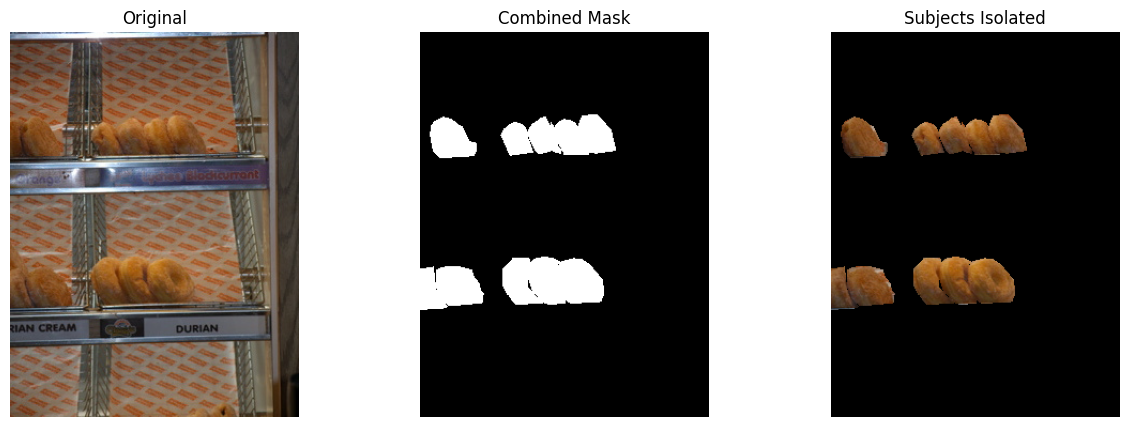

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import pycocotools.mask as mask_utils
import random

ann_file = "annotations/annotations/instances_val2017.json"
img_dir = "val2017"

coco = COCO(ann_file)

img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs([img_id])[0]

img_file = img_info['file_name']
img_path = glob.glob(f"{img_dir}/**/{img_file}", recursive=True)[0]

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image.shape[:2]

ann_ids = coco.getAnnIds(imgIds=[img_id])
anns = coco.loadAnns(ann_ids)

mask_list = []
for ann in anns:
    seg = ann['segmentation']
    if isinstance(seg, list):
        rle = mask_utils.frPyObjects(seg, h, w)
        rle = mask_utils.merge(rle)
        m = mask_utils.decode(rle)
    elif isinstance(seg, dict) and "counts" in seg:
        m = mask_utils.decode(seg)
    else:
        continue
    mask_list.append(m)

if mask_list:
    combined_mask = np.logical_or.reduce(mask_list).astype(np.uint8)
else:
    combined_mask = np.zeros((h, w), dtype=np.uint8)

overlay = image.copy()
overlay[combined_mask == 0] = 0

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(image); plt.axis('off'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(combined_mask, cmap='gray'); plt.axis('off'); plt.title("Combined Mask")
plt.subplot(1,3,3); plt.imshow(overlay); plt.axis('off'); plt.title("Subjects Isolated")
plt.show()


loading annotations into memory...
Done (t=0.34s)
creating index...
index created!


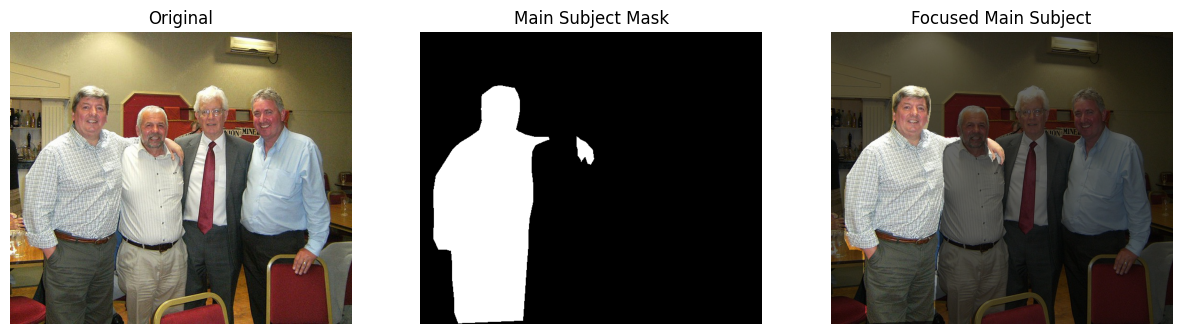

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import pycocotools.mask as mask_utils
import random
import glob

ann_file = "annotations/annotations/instances_val2017.json"
img_dir = "val2017"

coco = COCO(ann_file)

img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs([img_id])[0]

img_file = img_info['file_name']
img_path = glob.glob(f"{img_dir}/**/{img_file}", recursive=True)[0]

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image.shape[:2]

ann_ids = coco.getAnnIds(imgIds=[img_id])
anns = coco.loadAnns(ann_ids)

max_area = 0
main_mask = np.zeros((h, w), dtype=np.uint8)

for ann in anns:
    seg = ann['segmentation']
    if isinstance(seg, list):
        rle = mask_utils.frPyObjects(seg, h, w)
        rle = mask_utils.merge(rle)
        m = mask_utils.decode(rle)
    elif isinstance(seg, dict) and "counts" in seg:
        m = mask_utils.decode(seg)
    else:
        continue
    area = m.sum()
    if area > max_area:
        max_area = area
        main_mask = m

background_mask = 1 - main_mask

overlay = image.copy()
overlay[background_mask == 1] = [0, 0, 0]

final_output = cv2.addWeighted(image, 0.4, overlay, 0.6, 0)
final_output[main_mask == 1] = image[main_mask == 1]

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(image); plt.axis('off'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(main_mask, cmap='gray'); plt.axis('off'); plt.title("Main Subject Mask")
plt.subplot(1,3,3); plt.imshow(final_output); plt.axis('off'); plt.title("Focused Main Subject")
plt.show()


In [ ]:
!mkdir -p val2017 annotations

# Download val2017 images
!wget -q http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip -d val2017

# Download annotations
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip -d annotations

## Training loss for every few epochs

Using device: cuda

Starting Training on Oxford-IIIT Pet Dataset..
--- Epoch [1/25] Finished --- Avg Loss: 0.4306 --- LR: 0.001 ---
--- Epoch [2/25] Finished --- Avg Loss: 0.3303 --- LR: 0.001 ---
--- Epoch [3/25] Finished --- Avg Loss: 0.2892 --- LR: 0.001 ---
--- Epoch [4/25] Finished --- Avg Loss: 0.2542 --- LR: 0.001 ---
--- Epoch [5/25] Finished --- Avg Loss: 0.2321 --- LR: 0.001 ---


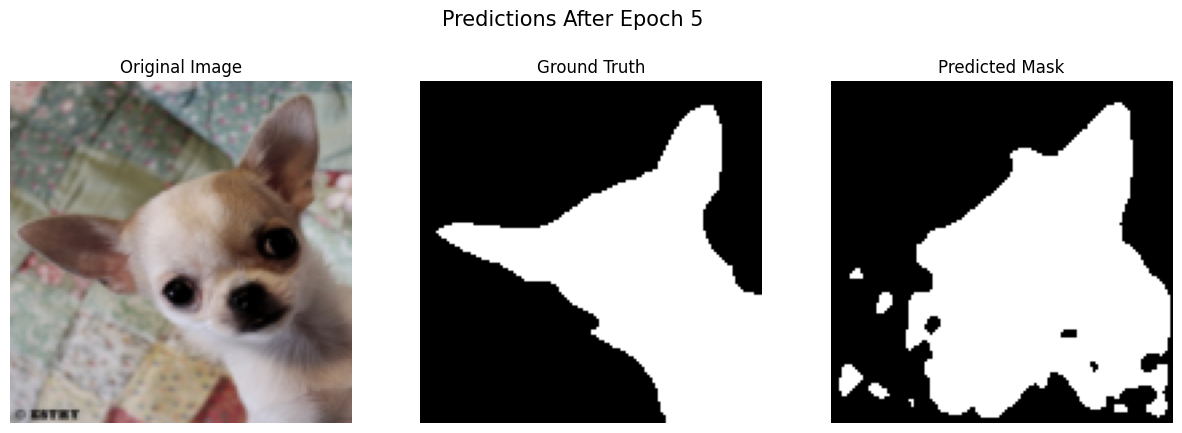

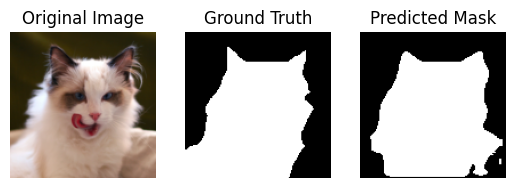

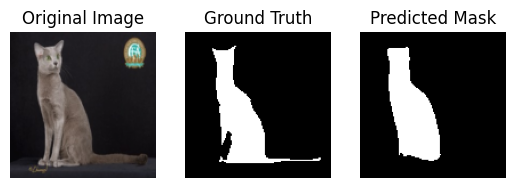

--- Epoch [6/25] Finished --- Avg Loss: 0.2158 --- LR: 0.001 ---
--- Epoch [7/25] Finished --- Avg Loss: 0.1994 --- LR: 0.001 ---
--- Epoch [8/25] Finished --- Avg Loss: 0.1710 --- LR: 0.0001 ---
--- Epoch [9/25] Finished --- Avg Loss: 0.1574 --- LR: 0.0001 ---
--- Epoch [10/25] Finished --- Avg Loss: 0.1540 --- LR: 0.0001 ---


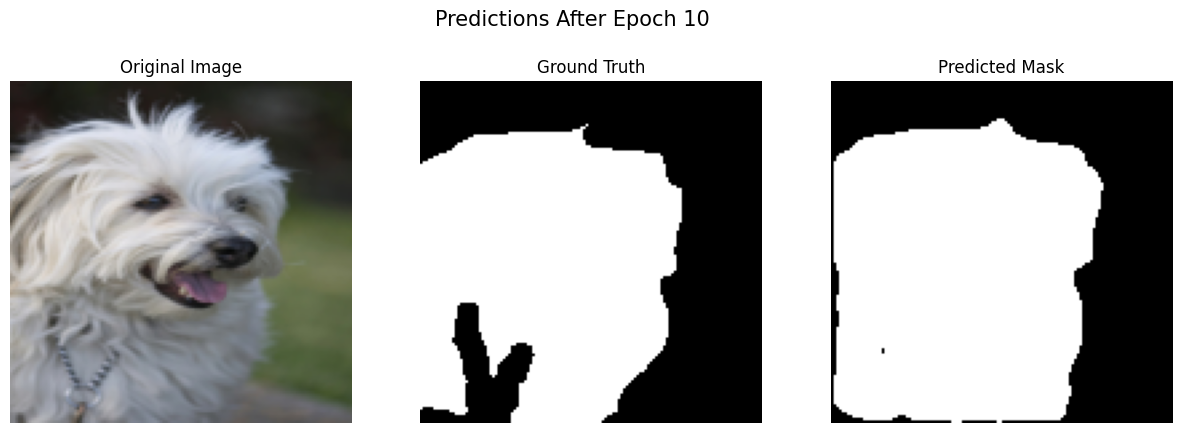

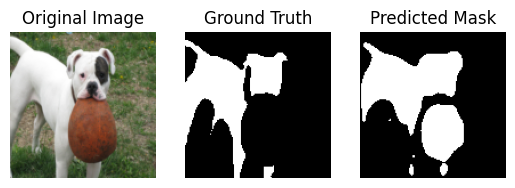

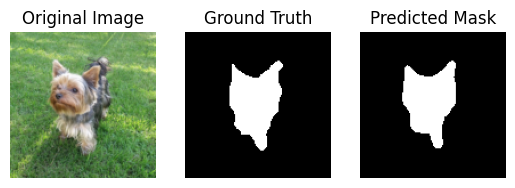

--- Epoch [11/25] Finished --- Avg Loss: 0.1488 --- LR: 0.0001 ---
--- Epoch [12/25] Finished --- Avg Loss: 0.1454 --- LR: 0.0001 ---
--- Epoch [13/25] Finished --- Avg Loss: 0.1400 --- LR: 0.0001 ---
--- Epoch [14/25] Finished --- Avg Loss: 0.1388 --- LR: 0.0001 ---
--- Epoch [15/25] Finished --- Avg Loss: 0.1333 --- LR: 1e-05 ---


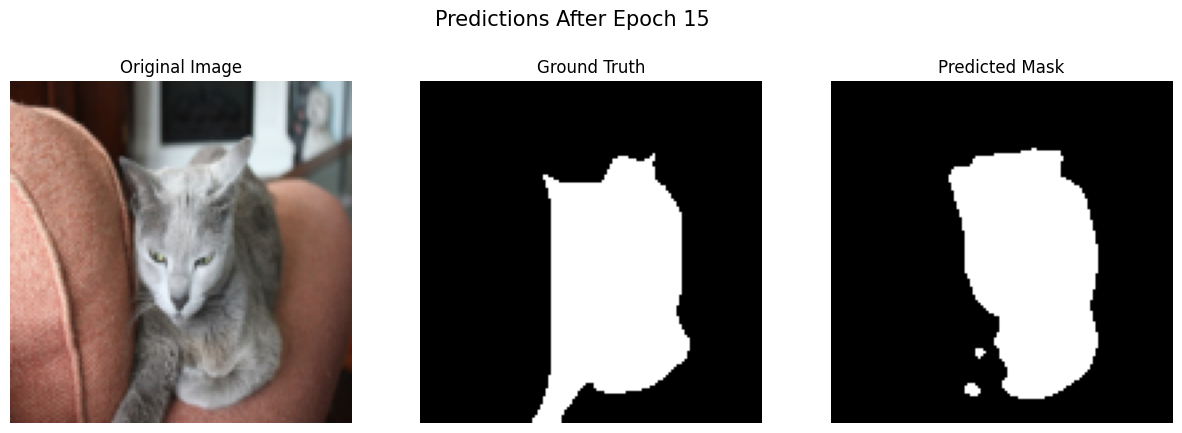

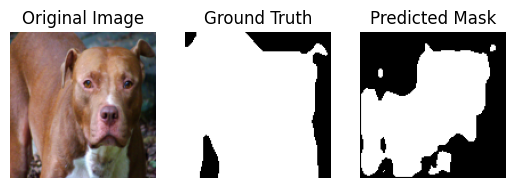

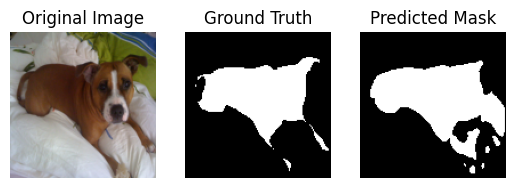

--- Epoch [16/25] Finished --- Avg Loss: 0.1315 --- LR: 1e-05 ---
--- Epoch [17/25] Finished --- Avg Loss: 0.1308 --- LR: 1e-05 ---
--- Epoch [18/25] Finished --- Avg Loss: 0.1305 --- LR: 1e-05 ---
--- Epoch [19/25] Finished --- Avg Loss: 0.1302 --- LR: 1e-05 ---
--- Epoch [20/25] Finished --- Avg Loss: 0.1291 --- LR: 1e-05 ---


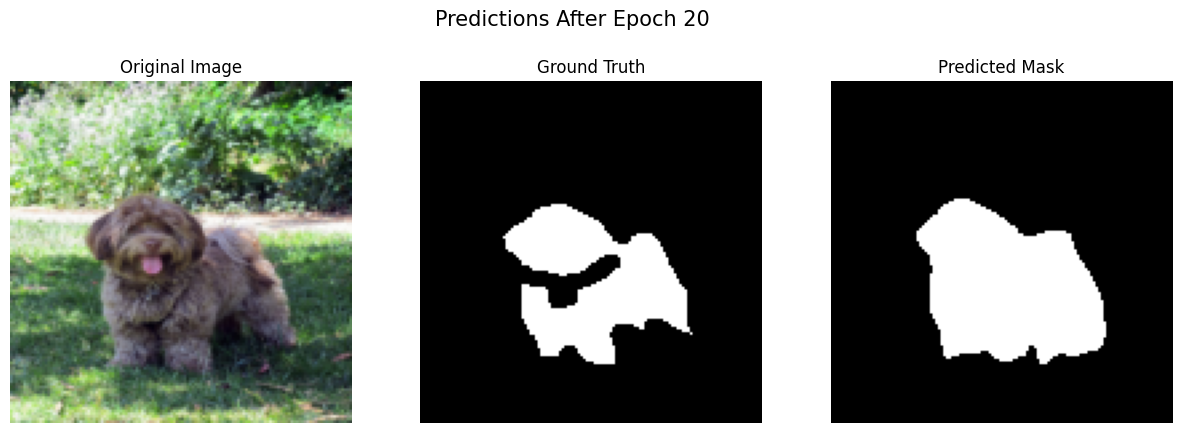

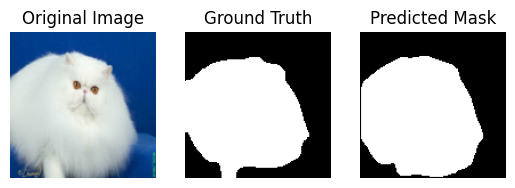

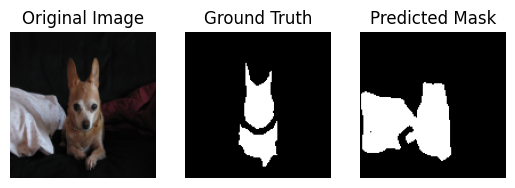

--- Epoch [21/25] Finished --- Avg Loss: 0.1285 --- LR: 1e-05 ---
--- Epoch [22/25] Finished --- Avg Loss: 0.1282 --- LR: 1.0000000000000002e-06 ---
--- Epoch [23/25] Finished --- Avg Loss: 0.1276 --- LR: 1.0000000000000002e-06 ---
--- Epoch [24/25] Finished --- Avg Loss: 0.1282 --- LR: 1.0000000000000002e-06 ---
--- Epoch [25/25] Finished --- Avg Loss: 0.1287 --- LR: 1.0000000000000002e-06 ---


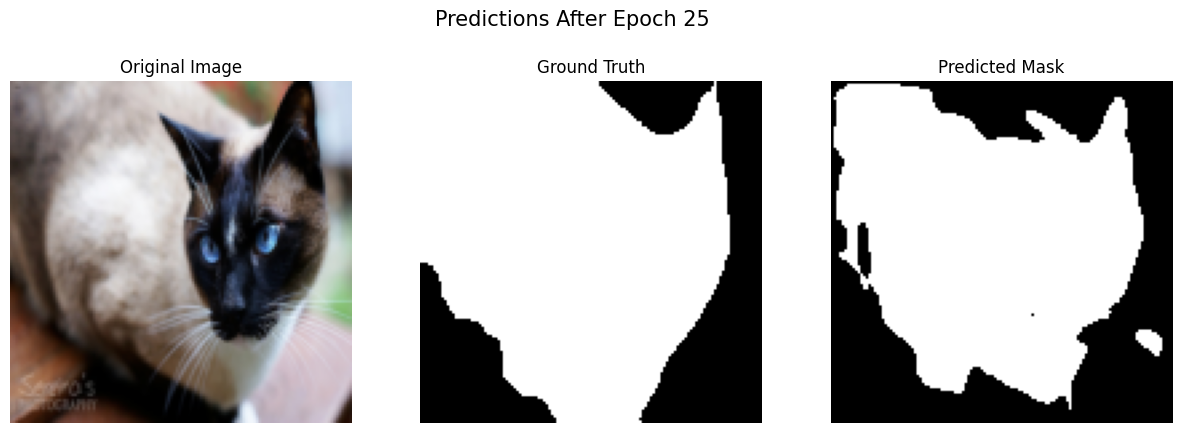

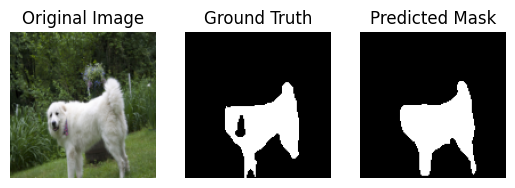

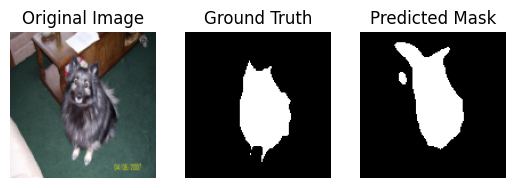

Training completed.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import v2 as T
import matplotlib.pyplot as plt

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.output_layer = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d4 = self.dec4(torch.cat((e4, self.upconv4(b)), dim=1))
        d3 = self.dec3(torch.cat((e3, self.upconv3(d4)), dim=1))
        d2 = self.dec2(torch.cat((e2, self.upconv2(d3)), dim=1))
        d1 = self.dec1(torch.cat((e1, self.upconv1(d2)), dim=1))
        return self.output_layer(d1)

class PetDataset(OxfordIIITPet):
    def __init__(self, root, split, common_transforms=None):
        super().__init__(root=root, split=split, download=True, target_types="segmentation")
        self.common_transforms = common_transforms
        self.normalize_image = T.Compose([
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __getitem__(self, idx):
        image, mask = super().__getitem__(idx)

        if self.common_transforms is not None:
            image, mask = self.common_transforms(image, mask)

        mask = (mask == 1).to(torch.float32)

        image = self.normalize_image(image)

        return image, mask

def show_predictions(model, loader, device, epoch):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.sigmoid(outputs) > 0.5

    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    plt.figure(figsize=(15, 5))
    plt.suptitle(f'Predictions After Epoch {epoch+1}', fontsize=15)

    for i in range(min(3, len(images))):
        img_display = inv_normalize(images[i]).cpu().permute(1, 2, 0).clamp(0, 1)

        plt.subplot(1, 3, 1)
        plt.imshow(img_display)
        plt.title('Original Image'); plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
        plt.title('Ground Truth'); plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(preds[i].cpu().squeeze(), cmap='gray')
        plt.title('Predicted Mask'); plt.axis('off')

        plt.show()

IMG_SIZE = 128
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
DATA_DIR = "./data"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

common_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToImage(),
])

train_dataset = PetDataset(root=DATA_DIR, split="trainval", common_transforms=common_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

val_dataset = PetDataset(root=DATA_DIR, split="test", common_transforms=common_transforms)
val_loader = DataLoader(val_dataset, batch_size=3, shuffle=True)

model = UNet(in_channels=3, out_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("\nStarting Training on Oxford-IIIT Pet Dataset..")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"--- Epoch [{epoch+1}/{NUM_EPOCHS}] Finished --- Avg Loss: {epoch_loss:.4f} --- LR: {current_lr} ---")

    scheduler.step()

    if (epoch + 1) % 5 == 0:
        show_predictions(model, val_loader, device, epoch)

print("Training completed.")
torch.save(model.state_dict(), "unet_trained.pth")

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/unet_trained.pth")
